# Ridge Regression Baseline

Linear regression with L2 (ridge) regularization trained on the same hand-crafted molecular descriptors as the boosting model. The regularization strength α is tuned against the held-out tuning set.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

In [2]:
df = pl.read_parquet("../data/processed/baseline_model_features.parquet")
print(df.shape)
df.head()

(3024, 38)


key,name,smiles,mpC,formula,C_count,H_count,O_count,N_count,S_count,F_count,Cl_count,Br_count,I_count,molecular_weight,branch_count,cycle_count,aromatic_ring_count,double_bond_count,triple_bond_count,carboxylic_acid_count,alcohol_count,carbonyl_count,prim_sec_amine_count,amide_count,hbd_count,hba_count,logp,tpsa,rotatable_bond_count,frac_csp3,stereocenters,bertz_ct,bridgehead_atoms,spiro_atoms,heterocycle_count,ring_atom_ratio,split
i64,str,str,f64,str,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,f64,i32,f64,i32,f64,i32,i32,i32,f64,str
27956,"""cyclobutylmethane""","""C1(CCC1)C""",-161.51,"""C5H10""",5,10,0,0,0,0,0,0,0,70.135,0,1,0,0,0,0,0,0,0,0,0,0,1.8064,0.0,0,1.0,0,27.01955,0,0,0,0.8,"""train"""
16005,"""Nitrogen oxide""","""[O-][N+]#N""",-90.8,"""N2O""",0,0,1,2,0,0,0,0,0,44.013,0,0,0,0,1,0,0,0,0,0,0,2,0.33728,51.21,0,0.0,0,24.264663,0,0,0,0.0,"""train"""
16127,"""Sulfuryl difluoride""","""FS(F)(=O)=O""",-135.8,"""F2O2S""",0,0,2,0,1,2,0,0,0,102.061,1,0,0,2,0,0,0,0,0,0,0,2,0.1702,34.14,0,0.0,0,90.816358,0,0,0,0.0,"""train"""
17138,"""disopyramide""","""CC(C)N(CCC(c1ccccn1)(c2ccccc2)…",94.8,"""C21H29N3O""",21,29,1,3,0,0,0,0,0,339.483,5,2,2,1,0,0,0,1,0,1,1,3,3.3619,59.22,8,0.428571,1,620.555222,0,0,1,0.48,"""train"""
15628,"""Bromine""","""BrBr""",-7.2,"""Br2""",0,0,0,0,0,0,0,2,0,159.808,0,0,0,0,0,0,0,0,0,0,0,0,1.6912,0.0,0,0.0,0,0.0,0,0,0,0.0,"""test"""


## Train / Tune / Test Split

Split assignments are loaded from `baseline_model_features.parquet` (assigned in `01_feature_engineering`).

In [3]:
FEATURE_COLS = [c for c in df.columns if c not in ("key", "name", "smiles", "mpC", "formula", "split")]

train_df = df.filter(pl.col("split") == "train")
tune_df  = df.filter(pl.col("split") == "tune")
test_df  = df.filter(pl.col("split") == "test")

X_train   = train_df.select(FEATURE_COLS).to_numpy()
X_tune    = tune_df.select(FEATURE_COLS).to_numpy()
X_test    = test_df.select(FEATURE_COLS).to_numpy()
y_train   = train_df["mpC"].to_numpy()
y_tune    = tune_df["mpC"].to_numpy()
y_test    = test_df["mpC"].to_numpy()
keys_test = test_df["key"].to_numpy()

print(f"Train: {len(X_train)}  Tune: {len(X_tune)}  Test: {len(X_test)}")

Train: 2116  Tune: 299  Test: 609


## Feature Scaling

Ridge regression is sensitive to feature scale. Fit `StandardScaler` on the training set only and apply to tune and test.

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_tune_s  = scaler.transform(X_tune)
X_test_s  = scaler.transform(X_test)

## Tune α

Search 100 values of α on a log scale from 10⁻² to 10⁵. Pick the value with the lowest MAE on the tuning set.

In [5]:
alphas = np.logspace(-2, 5, 100)
tune_maes = []

for alpha in alphas:
    preds = Ridge(alpha=alpha).fit(X_train_s, y_train).predict(X_tune_s)
    tune_maes.append(mean_absolute_error(y_tune, preds))

best_alpha = alphas[np.argmin(tune_maes)]
print(f"Best α: {best_alpha:.4f}  (tune MAE: {min(tune_maes):.2f} °C)")

Best α: 0.8111  (tune MAE: 38.48 °C)


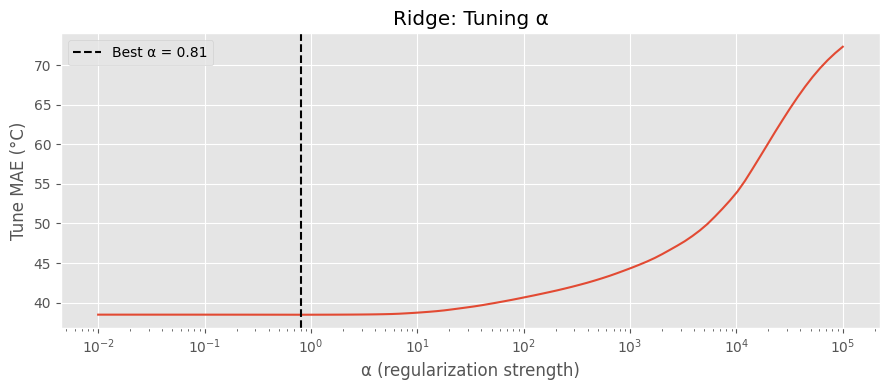

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(alphas, tune_maes)
ax.axvline(best_alpha, color="k", linestyle="--", label=f"Best α = {best_alpha:.2f}")
ax.set_xlabel("α (regularization strength)")
ax.set_ylabel("Tune MAE (°C)")
ax.set_title("Ridge: Tuning α")
ax.legend()
plt.tight_layout()
plt.show()

## Test Set Evaluation

In [7]:
model = Ridge(alpha=best_alpha).fit(X_train_s, y_train)

ridge_preds = model.predict(X_test_s)
ridge_mae   = mean_absolute_error(y_test, ridge_preds)
ridge_rmse  = root_mean_squared_error(y_test, ridge_preds)
print(f"Ridge — Test MAE:  {ridge_mae:.2f} °C")
print(f"Ridge — Test RMSE: {ridge_rmse:.2f} °C")

Ridge — Test MAE:  40.26 °C
Ridge — Test RMSE: 54.59 °C


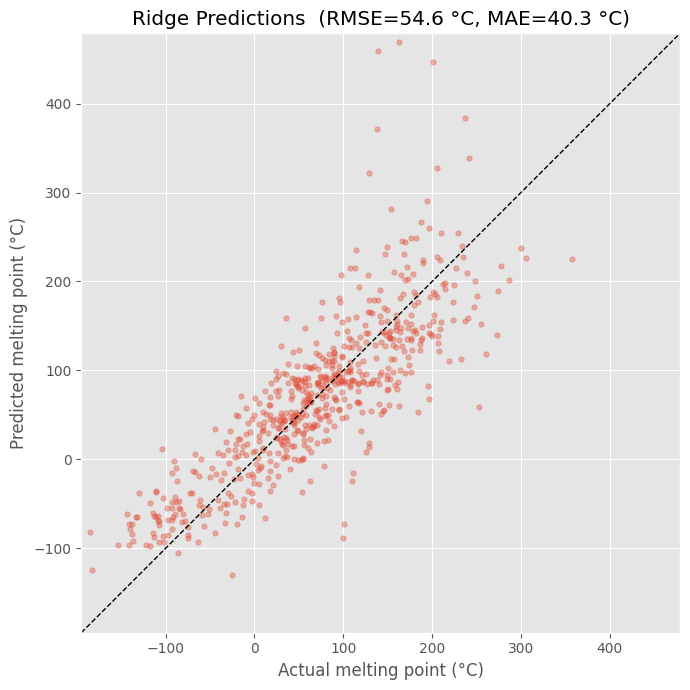

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, ridge_preds, alpha=0.4, s=15)
lims = [min(y_test.min(), ridge_preds.min()) - 10,
        max(y_test.max(), ridge_preds.max()) + 10]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual melting point (°C)")
ax.set_ylabel("Predicted melting point (°C)")
ax.set_title(f"Ridge Predictions  (RMSE={ridge_rmse:.1f} °C, MAE={ridge_mae:.1f} °C)")
plt.tight_layout()
plt.show()

## Coefficients

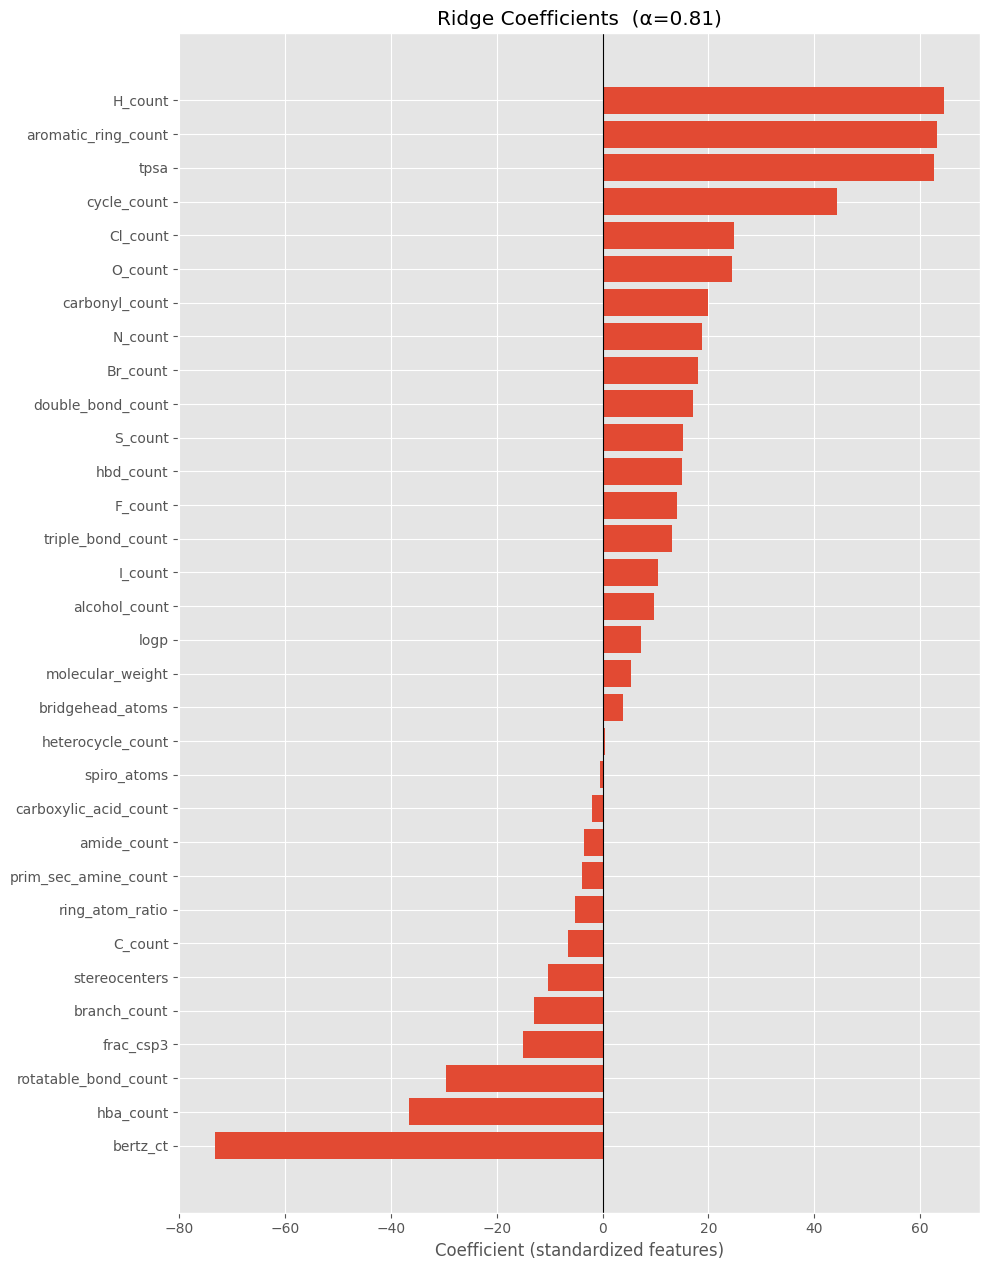

In [9]:
coef = model.coef_
sorted_idx = np.argsort(coef)

fig, ax = plt.subplots(figsize=(10, len(FEATURE_COLS) * 0.4))
ax.barh([FEATURE_COLS[i] for i in sorted_idx], coef[sorted_idx])
ax.axvline(0, color="k", linewidth=0.8)
ax.set_xlabel("Coefficient (standardized features)")
ax.set_title(f"Ridge Coefficients  (α={best_alpha:.2f})")
plt.tight_layout()
plt.savefig("../img/ridge_coefs.png")
plt.show()

## Save Predictions

In [10]:
os.makedirs("../data/predictions", exist_ok=True)
(
    pl.DataFrame({
        "key":    keys_test.tolist(),
        "y_true": y_test.tolist(),
        "y_pred": ridge_preds.tolist(),
    })
    .write_parquet("../data/predictions/ridge_predictions.parquet")
)
print("Saved Ridge test predictions.")

Saved Ridge test predictions.
